# **Uncertainty evaluation**

Three methods compared head-to-head against the baseline:
- **MC Dropout** at baseline p=0.3 (no retraining, T=30 forward passes)
- **MC Dropout** at p=0.5 (retrained from baseline warm start, T=30)
- **Deep ensemble** of 5 ResNet-50s (seeds 42..46; seed 42 == baseline ckpt)
- **Evidential** (Sensoy 2018) - Dirichlet head, single forward pass
- **Temperature scaling** - post-hoc calibration on the baseline

For each method: calibration (reliability, ECE, MCE, Brier), selective prediction
(risk-coverage, AURC, risk@80/90), error-detection AUROC, and per-grade entropy.

As per Category 2, AI was used to proofread code

## 1. Setup


In [1]:
from dataclasses import dataclass, field, replace
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
import json, math, time
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.optim import AdamW, LBFGS
from tqdm.auto import tqdm

# baseline pipeline
from mmac_utils import *

# output dirs
UNC_OUTPUT_DIR: Path = OUTPUT_DIR / "uncertainty"
UNC_ARTEFACT_DIR: Path = ARTEFACT_DIR / "uncertainty"
for d in (UNC_OUTPUT_DIR, UNC_ARTEFACT_DIR): d.mkdir(parents=True, exist_ok=True)

device = get_device()
print(f"device = {device}, baseline ckpt exists = {BASELINE_CKPT.is_file()}")

device = cpu, baseline ckpt exists = True


/home/sami/Documents/UCL/MPHY0050/AppliedAIGroupProject/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Configuration

In [ ]:
@dataclass
class UncConfig:
    seed: int = 42
    image_size: int = 224
    val_split: float = 0.15
    num_workers: int = 4
    batch_size: int = 64
    dropout: float = 0.3 
    method: str = "ce"
    kl_weight_max: float = 1.0
    kl_anneal_epochs: int = 10
    epochs: int = 20
    head_lr: float = 1e-3
    backbone_lr: float = 1e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 1
    label_smoothing: float = 0.0
    grad_clip: float = 1.0
    use_amp: bool = True
    early_stop_patience: int = 7
    primary_metric: str = "quadratic_kappa"
    warm_start_mode: str = "full"
    experiment_name: str = "unc_run"

    def as_dict(self) -> Dict[str, Any]:
        return {k: (str(v) if isinstance(v, Path) else v) for k, v in self.__dict__.items()}


main_cfg = UncConfig()
ENSEMBLE_SEEDS: Tuple[int, ...] = (42, 43, 44, 45, 46)
MCD_T: int = 30 # MC-Dropout forward passes
TRAIN: bool = False # False to load checkpoints instead of retrain
RELOAD_ONLY: bool = True # set True to skip inference

set_seed(main_cfg.seed); enable_cuda_optimizations() # fast cuda kernels

## 3. Models - baseline + evidential subclass

In [ ]:
class MMACEvidentialResNet50(MMACResNet50):
    """same architecture, Dirichlet interpretation at inference."""
    def evidence(self, x):
        return F.softplus(self.forward(x))
    def alpha(self, x):
        return self.evidence(x) + 1.0

## 4. Training

In [ ]:
def _kl_dirichlet_to_uniform(alpha: torch.Tensor) -> torch.Tensor:
    """KL(Dir(alpha) || Dir(1)) per sample, shape (B,). Sensoy et al. eq. A5."""
    # K = number of classes, S = sum of dirichlet params per sample
    K = alpha.size(-1)
    S = alpha.sum(dim=-1, keepdim=True)
    # first: log Gamma(S) - sum log Gamma(alpha_k) - log Gamma(K)
    first = (torch.lgamma(S.squeeze(-1)) - torch.lgamma(alpha).sum(dim=-1)
             - torch.lgamma(torch.tensor(float(K), device=alpha.device)))
    # second: sum (alpha_k - 1) * (digamma(alpha_k) - digamma(S))
    # digamma because d/dx log Gamma(x) = digamma(x)
    second = ((alpha - 1.0) * (torch.digamma(alpha) - torch.digamma(S))).sum(dim=-1)
    return first + second


def evidential_loss(logits: torch.Tensor, target: torch.Tensor, *, kl_weight: float
                    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """expected squared-error under Dirichlet + KL to uniform prior."""
    alpha = F.softplus(logits) + 1.0
    S = alpha.sum(dim=-1, keepdim=True)
    prob = alpha / S # dirichlet mean = predictive distribution
    y = F.one_hot(target, num_classes=logits.size(-1)).float() # one-hot target

    mse = ((y - prob) ** 2).sum(dim=-1)
    var = (alpha * (S - alpha) / (S ** 2 * (S + 1.0))).sum(dim=-1)

    alpha_tilde = y + (1.0 - y) * alpha
    kl = _kl_dirichlet_to_uniform(alpha_tilde)

    total = (mse + var + kl_weight * kl).mean()
    return total, {"data": (mse + var).mean().detach(), "kl": kl.mean().detach()}


def _forward_loss(model, x, target, method, ce_loss, kl_weight):
    # one forward pass, then dispatch to the right loss
    logits = model(x)
    if method == "ce":
        return logits, ce_loss(logits, target), {}
    # evidential gets an extras dict (data term + kl term) for logging
    total, parts = evidential_loss(logits, target, kl_weight=kl_weight)
    return logits, total, parts


def _predict_probs(logits: torch.Tensor, method: str) -> torch.Tensor:
    # CE predictions are softmax, evidential predictions are dirichlet mean alpha/S
    if method == "ce":
        return torch.softmax(logits, dim=-1)
    alpha = F.softplus(logits) + 1.0
    return alpha / alpha.sum(dim=-1, keepdim=True)


def _run_epoch(model, loader, device, *, method, ce_loss, kl_weight, optimizer=None,
               grad_clip=0.0, use_amp=False, desc="eval"):

    training = optimizer is not None
    model.train(training)
    scaler = amp_scaler(use_amp, device) if training else None # AMP scaler only on train+cuda
    running = 0.0; extras = defaultdict(float); seen = 0
    ys, ps, prs, logs = [], [], [], [] # truths, preds, probs, raw logits (eval only)
    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    with (torch.enable_grad() if training else torch.no_grad()):
        for x, y in pbar:
            x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
            if training: optimizer.zero_grad(set_to_none=True)
            # autocast for fp16 forward+loss under AMP, no-op otherwise
            with amp_ctx(use_amp, device):
                logits, loss, parts = _forward_loss(model, x, y, method, ce_loss, kl_weight)
            if training:
                # AMP dance: scale -> backward -> unscale for clip -> step -> update
                if scaler is not None:
                    scaler.scale(loss).backward()
                    if grad_clip > 0:
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    scaler.step(optimizer); scaler.update()
                else:
                    # plain fp32 path (CPU / MPS)
                    loss.backward()
                    if grad_clip > 0: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                    optimizer.step()

            # sample-weighted running averages
            bs = x.size(0); seen += bs
            running += float(loss.detach()) * bs
            for k, v in parts.items(): extras[k] += float(v) * bs

            with torch.no_grad():
                prob = _predict_probs(logits.detach(), method).float().cpu().numpy()
            prs.append(prob); ps.append(prob.argmax(axis=1))
            ys.append(y.detach().cpu().numpy())
            if not training: logs.append(logits.detach().float().cpu().numpy())
            pbar.set_postfix(loss=f"{running / max(seen,1):.4f}")

    # concatenate per-batch arrays for the epoch-level metrics
    y_true = np.concatenate(ys) if ys else np.array([], dtype=int)
    y_pred = np.concatenate(ps) if ps else np.array([], dtype=int)
    y_prob = np.concatenate(prs) if prs else np.empty((0, 0))
    y_logit = np.concatenate(logs) if logs else np.empty((0, 0))
    bundle = compute_metrics(y_true, y_pred, y_prob)
    return running / max(seen, 1), bundle, {k: v / max(seen, 1) for k, v in extras.items()}, \
           y_true, y_pred, y_prob, y_logit


def train_model(model: MMACResNet50, loaders: Dict[str, Any], cfg: UncConfig,
                device: torch.device) -> Path:
    model.to(device)
    ce_loss = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing).to(device)
    # same two-LR-group setup as baseline: slow backbone, faster head
    groups = unwrap_model(model).parameter_groups(cfg.backbone_lr, cfg.head_lr, cfg.weight_decay)
    optimizer = AdamW(groups)
    scheduler = build_cosine_with_warmup(optimizer, cfg.epochs, cfg.warmup_epochs)
    history = TrainingHistory()
    # early stopping recording
    best_metric, best_epoch, patience = -math.inf, -1, cfg.early_stop_patience
    use_amp = cfg.use_amp and device.type == "cuda"
    best_ckpt = CHECKPOINT_DIR / f"{cfg.experiment_name}_best.pt"
    last_ckpt = CHECKPOINT_DIR / f"{cfg.experiment_name}_last.pt"
    print(f"[train] method={cfg.method} epochs={cfg.epochs}")

    for ep in range(cfg.epochs):
        t0 = time.time()
        # evidence time to grow before the regulariser pushes it back to the prior
        kl_w = float(cfg.kl_weight_max * min(1.0, (ep + 1) / max(1, cfg.kl_anneal_epochs))) \
               if cfg.method == "evidential" else 0.0
        tr_loss, tr_bundle, tr_extras, *_ = _run_epoch(
            model, loaders["train"], device, method=cfg.method, ce_loss=ce_loss,
            kl_weight=kl_w, optimizer=optimizer, grad_clip=cfg.grad_clip,
            use_amp=use_amp, desc=f"train {ep+1}/{cfg.epochs}")
        va_loss, va_bundle, *_ = _run_epoch(
            model, loaders["val"], device, method=cfg.method, ce_loss=ce_loss,
            kl_weight=kl_w, desc=f"val {ep+1}/{cfg.epochs}")
        scheduler.step() # once-per-epoch cosine (after 1-epoch linear warmup)

        history.append(train_loss=tr_loss, val_loss=va_loss,
                       train_metrics=tr_bundle.to_dict(), val_metrics=va_bundle.to_dict(),
                       learning_rates=[pg["lr"] for pg in optimizer.param_groups],
                       extra={"kl_weight": kl_w, **tr_extras})

        # track best val metric, reset patience on improvement
        cur = getattr(va_bundle, cfg.primary_metric) or -math.inf
        improved = cur > best_metric
        tail = f" kl_w={kl_w:.2f}" if cfg.method == "evidential" else ""
        print(f"[epoch {ep+1:02d}/{cfg.epochs}] {'*' if improved else ' '} "
              f"train={tr_loss:.4f} | val={va_loss:.4f} {va_bundle.pretty()}{tail} "
              f"| {time.time()-t0:.1f}s")

        # save every epoch (last) + only when improved (best)
        ckpt_extra = {"config": cfg.as_dict(), "kl_weight": kl_w}
        save_checkpoint(last_ckpt, model=model, optimizer=optimizer, scheduler=scheduler,
                        epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        if improved:
            best_metric, best_epoch, patience = cur, ep, cfg.early_stop_patience
            save_checkpoint(best_ckpt, model=model, optimizer=optimizer, scheduler=scheduler,
                            epoch=ep, metrics=va_bundle.to_dict(), extra=ckpt_extra)
        else:
            patience -= 1
            if patience <= 0:
                print(f"[train] early stop at epoch {ep+1}"); break
        # flush history after every epoch so a crash leaves usable JSON behind
        history.save(UNC_ARTEFACT_DIR / f"{cfg.experiment_name}_history.json")

    return best_ckpt


## 5. Uncertainty quantities

In [ ]:
EPS = 1e-12 # for log(0) when probs are numerically zero

def predictive_entropy(prob: np.ndarray, axis: int = -1) -> np.ndarray:
    # H(p) = -sum p log p, one scalar per sample
    p = np.clip(prob, EPS, 1.0)
    return -np.sum(p * np.log(p), axis=axis)


def mean_prob_and_entropy(samples: np.ndarray):
    """given (T, N, C) stochastic probs: (mean_prob, H_total, mutual_info)."""
    if samples.ndim != 3:
        raise ValueError(f"expected (T, N, C); got {samples.shape}")
    mean_prob = samples.mean(axis=0)
    H_mean = predictive_entropy(mean_prob)
    E_H = predictive_entropy(samples, axis=-1).mean(axis=0)
    mi = np.clip(H_mean - E_H, 0.0, None)
    return mean_prob, H_mean, mi


def max_softmax_uncertainty(prob: np.ndarray) -> np.ndarray:
    return 1.0 - prob.max(axis=-1)


def dirichlet_vacuity(alpha: np.ndarray) -> np.ndarray:
    # vacuity = K / sum(alpha): bounded [0, 1], near 1 = little evidence, near 0 = lots
    K = alpha.shape[-1]
    return K / alpha.sum(axis=-1)


def expected_calibration_error(prob, y_true, *, n_bins=15) -> Dict[str, Any]:
    """reliability bins + ECE / MCE."""
    # bin samples by their confidence (max softmax), check accuracy inside each bin
    confs = prob.max(axis=-1)
    preds = prob.argmax(axis=-1)
    correct = (preds == y_true).astype(np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # digitize -> bin index per sample; clip to keep everything in [0, n_bins-1]
    bin_idx = np.clip(np.digitize(confs, edges[1:-1], right=True), 0, n_bins - 1)
    bin_count = np.zeros(n_bins, dtype=np.int64)
    bin_conf  = np.zeros(n_bins, dtype=np.float64)
    bin_acc   = np.zeros(n_bins, dtype=np.float64)
    for b in range(n_bins):
        m = bin_idx == b
        bin_count[b] = int(m.sum())
        if bin_count[b]:
            # average confidence + accuracy inside the bin
            bin_conf[b] = float(confs[m].mean())
            bin_acc[b]  = float(correct[m].mean())
    w = bin_count / max(len(y_true), 1) # per-bin weight = share of samples
    gaps = np.abs(bin_conf - bin_acc)
    # ECE = weighted mean |conf - acc|; MCE = worst-case |conf - acc| over non-empty bins
    ece = float((gaps * w).sum())
    mce = float(gaps[bin_count > 0].max()) if bin_count.sum() else 0.0
    return {"ece": ece, "mce": mce, "n_bins": n_bins,
            "bin_count": bin_count.tolist(), "bin_conf": bin_conf.tolist(),
            "bin_acc":  bin_acc.tolist(),   "bin_edges": edges.tolist()}


def brier_score(prob, y_true, num_classes: int = NUM_CLASSES) -> float:
    # mean squared error between predictive distribution and one-hot target
    oh = np.eye(num_classes)[y_true.astype(int)]
    return float(np.mean(np.sum((prob - oh) ** 2, axis=-1)))


def selective_prediction(prob, y_true, uncertainty) -> Dict[str, Any]:
    """risk-coverage curve. coverage = fraction kept after abstaining on most uncertain."""
    y_pred = prob.argmax(axis=-1)
    err = (y_pred != y_true).astype(np.float64)
    order = np.argsort(uncertainty)
    # risk[k] = error rate over the k most confident predictions (cumulative error rate)
    risks = np.cumsum(err[order]) / np.arange(1, len(y_true) + 1)
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    aurc = float(np.trapezoid(risks, coverages))
    
    def _at(c: float) -> float:
        k = max(1, int(round(c * len(y_true))))
        return float(risks[k - 1])
    return {"aurc": aurc, "coverages": coverages, "risks": risks,
            "risk@80": _at(0.8), "risk@90": _at(0.9), "risk@100": _at(1.0)}


def error_detection_auroc(uncertainty, y_true, prob) -> float:
    # high AUROC means the uncertainty signal ranks wrong predictions above right ones
    y_pred = prob.argmax(axis=-1)
    is_err = (y_pred != y_true).astype(int)
    # degenerate cases (all right / all wrong) leave AUROC undefined
    if is_err.sum() in (0, len(is_err)):
        return float("nan")
    return float(roc_auc_score(is_err, uncertainty))

## 6. Prediction helpers - MCD, ensemble, evidential, temperature

In [ ]:
def _set_mc_dropout(model: nn.Module) -> None:
    # BN in eval (frozen running stats), Dropout in train (stochastic)
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            m.train()


@torch.no_grad()
def predict_deterministic(model, loader, device, method: str = "ce"):
    # plain single-pass prediction used by baseline + ensemble members
    model.eval()
    ys, probs = [], []
    for x, y in tqdm(loader, desc="predict", leave=False, dynamic_ncols=True):
        x = x.to(device, non_blocking=True)
        prob = _predict_probs(model(x), method).float().cpu().numpy()
        probs.append(prob); ys.append(y.numpy())
    return np.concatenate(ys).astype(np.int64), np.concatenate(probs).astype(np.float32)


@torch.no_grad()
def predict_mc_dropout(model, loader, device, *, T: int = 30):
    """T stochastic forward passes with dropout active. Returns (y, (T,N,C) probs)."""
    y_ref = None
    passes: List[np.ndarray] = []
    for t in range(T):
        # re-enable dropout each pass
        _set_mc_dropout(model)
        probs_t, ys_t = [], []
        for x, y in tqdm(loader, desc=f"MCD {t+1}/{T}", leave=False, dynamic_ncols=True):
            x = x.to(device, non_blocking=True)
            probs_t.append(torch.softmax(model(x), dim=-1).float().cpu().numpy())
            ys_t.append(y.numpy())
        probs_t = np.concatenate(probs_t).astype(np.float32)
        ys_t = np.concatenate(ys_t).astype(np.int64)
        # determinism check: each pass must visit samples in the same order so probs line up per-row
        if y_ref is None: y_ref = ys_t
        else: assert np.array_equal(y_ref, ys_t), "loader order drifted"
        passes.append(probs_t)
    # stack into (T, N, C) for downstream MI / mean-entropy computation
    return y_ref, np.stack(passes, axis=0)


@torch.no_grad()
def predict_dirichlet(model, loader, device):
    """evidential single-pass. Returns (y, prob=alpha/S, alpha)."""
    # no sampling at inference - the Dirichlet mean is deterministic given the logits
    model.eval()
    ys, probs, alphas = [], [], []
    for x, y in tqdm(loader, desc="evidential", leave=False, dynamic_ncols=True):
        x = x.to(device, non_blocking=True)
        # alpha = softplus(logit) + 1 (same parameterisation as training)
        alpha = F.softplus(model(x)) + 1.0
        prob = alpha / alpha.sum(dim=-1, keepdim=True) # dirichlet mean
        alphas.append(alpha.float().cpu().numpy())
        probs.append(prob.float().cpu().numpy())
        ys.append(y.numpy())
    return (np.concatenate(ys).astype(np.int64),
            np.concatenate(probs).astype(np.float32),
            np.concatenate(alphas).astype(np.float32))


def fit_temperature(val_logits, val_labels, device, *, max_iter: int = 100) -> float:
    """fit a scalar temperature by LBFGS on validation NLL."""
    # optimise in log-space (log_T) so T = exp(log_T) stays positive without a constraint
    logits = torch.as_tensor(val_logits, dtype=torch.float32, device=device)
    labels = torch.as_tensor(val_labels, dtype=torch.long,    device=device)
    log_T = torch.zeros(1, device=device, requires_grad=True) # T = exp(log_T), init T=1
    opt = LBFGS([log_T], lr=0.1, max_iter=max_iter)
    ce = nn.CrossEntropyLoss()
    def closure():
        # LBFGS needs a closure that re-evaluates loss + grads
        opt.zero_grad()
        loss = ce(logits / torch.exp(log_T), labels)
        loss.backward()
        return loss
    opt.step(closure)
    return float(torch.exp(log_T).detach().cpu())


def apply_temperature(logits, T: float) -> np.ndarray:
    # rescale logits then softmax - argmax (and therefore accuracy / kappa) is unchanged
    return torch.softmax(torch.as_tensor(logits, dtype=torch.float32) / float(T), dim=-1).numpy()


## 7. Run methods

In [ ]:
set_seed(main_cfg.seed)
if RELOAD_ONLY:
    loaders = None
else:
    loaders = build_dataloaders(main_cfg.image_size, main_cfg.batch_size,
                                main_cfg.num_workers, main_cfg.val_split, main_cfg.seed)
    print(f"Train/Val/Test: {len(loaders['train_ds'])} / "
          f"{len(loaders['val_ds'])} / {len(loaders['test_ds'])}")

method_outputs: Dict[str, Dict[str, Any]] = {}

def _save_npz(name: str, *, y_true, y_pred, y_prob, **extra):
    np.savez_compressed(
        UNC_ARTEFACT_DIR / f"{name}_test_predictions.npz",
        y_true=y_true.astype(np.int64), y_pred=y_pred.astype(np.int64),
        y_prob=y_prob.astype(np.float32),
        **{k: (v.astype(np.float32) if isinstance(v, np.ndarray) else v) for k, v in extra.items()},
    )

### 7.1 MC Dropout at baseline p=0.3 (no retraining)


In [ ]:
def _reload_unc_npz(name: str) -> Optional[Dict[str, Any]]:
    p = UNC_ARTEFACT_DIR / f"{name}_test_predictions.npz"
    if not p.is_file(): return None
    d = np.load(p)
    y_true, y_pred, y_prob = d["y_true"], d["y_pred"], d["y_prob"]
    bundle = compute_metrics(y_true, y_pred, y_prob)
    print(f"[{name}] RELOAD_ONLY  TEST {bundle.pretty()}")
    out: Dict[str, Any] = {"name": name, "bundle": bundle,
                           "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

    for k in d.files:
        if k not in out: out[k] = d[k]
    return out


def run_mcd(name: str, dropout: float, ckpt_path: Path, *, T: int = MCD_T) -> Dict[str, Any]:
    if RELOAD_ONLY:
        r = _reload_unc_npz(name)
        if r is None: raise FileNotFoundError(f"RELOAD_ONLY: no NPZ for {name}")
        return r
    # MC-Dropout: no retraining for p=0.3 variant, just reload baseline and sample T passes
    model = MMACResNet50(NUM_CLASSES, pretrained=False, dropout=dropout).to(device)
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"no checkpoint at {ckpt_path}")
    load_checkpoint(ckpt_path, model=model, map_location=device)

    # T stochastic forward passes -> stack of probs per sample
    y_true, prob_T = predict_mc_dropout(model, loaders["test"], device, T=T)
    # mean prob = final prediction; H(mean) = total uncertainty; MI = epistemic
    mean_prob, H, mi = mean_prob_and_entropy(prob_T)
    y_pred = mean_prob.argmax(axis=-1)
    bundle = compute_metrics(y_true, y_pred, mean_prob)
    print(f"[{name}] TEST {bundle.pretty()}")

    # persist the full stochastic stack
    _save_npz(name, y_true=y_true, y_pred=y_pred, y_prob=mean_prob,
              mc_samples=prob_T, entropy=H, mutual_info=mi,
              max_sm_unc=max_softmax_uncertainty(mean_prob))
    return {"name": name, "bundle": bundle, "y_true": y_true, "y_pred": y_pred,
            "y_prob": mean_prob, "entropy": H, "mutual_info": mi,
            "max_sm_unc": max_softmax_uncertainty(mean_prob)}


# baseline dropout rate, no retraining - purely an inference-time change
method_outputs["unc_mcd"] = run_mcd("unc_mcd", dropout=0.3, ckpt_path=BASELINE_CKPT)


[unc_mcd] RELOAD_ONLY  TEST acc=0.7258  bal_acc=0.6265  macroF1=0.6647  kappa=0.7914  AUROC=0.9203


### 7.2 MC Dropout at p=0.5 (retrained from baseline warm start)


In [19]:
mcd_p5_ckpt = CHECKPOINT_DIR / "unc_mcd_p5_best.pt"
# p=0.5 needs retraining because the baseline wasn't trained with that dropout rate
if RELOAD_ONLY:
    # pure reload path - run_mcd short-circuits on NPZ, ckpt isn't needed
    method_outputs["unc_mcd_p5"] = run_mcd("unc_mcd_p5", dropout=0.5, ckpt_path=mcd_p5_ckpt)
elif TRAIN and not mcd_p5_ckpt.is_file():
    # backbone warm-start: reuse baseline features, train the head fresh under higher dropout
    cfg = replace(main_cfg, experiment_name="unc_mcd_p5", dropout=0.5, warm_start_mode="backbone")
    set_seed(cfg.seed)
    model = MMACResNet50(NUM_CLASSES, pretrained=True, dropout=cfg.dropout)
    warm_start_from_ckpt(model, BASELINE_CKPT, backbone_only=True)
    mcd_p5_ckpt = train_model(model, loaders, cfg, device)
elif not mcd_p5_ckpt.is_file():
    # nothing to do if neither TRAIN nor a prior checkpoint
    print("[unc_mcd_p5] missing checkpoint and TRAIN=False - skipping")

# once the ckpt exists, sample T MC-Dropout passes exactly like the p=0.3 variant
if not RELOAD_ONLY and mcd_p5_ckpt.is_file():
    method_outputs["unc_mcd_p5"] = run_mcd("unc_mcd_p5", dropout=0.5, ckpt_path=mcd_p5_ckpt)


[unc_mcd_p5] RELOAD_ONLY  TEST acc=0.7177  bal_acc=0.6074  macroF1=0.6274  kappa=0.8364  AUROC=0.9196


### 7.3 Deep ensemble


In [ ]:
def _ensemble_ckpt(seed: int) -> Path:
    return BASELINE_CKPT if seed == 42 else CHECKPOINT_DIR / f"unc_ens_seed{seed}_best.pt"


def _train_ensemble_member(seed: int) -> Path:
    # one member: backbone warm-started, head retrained from scratch with this seed
    cfg = replace(main_cfg, experiment_name=f"unc_ens_seed{seed}", seed=seed,
                  warm_start_mode="backbone")
    set_seed(cfg.seed)
    # each seed gets its own dataloaders - different split order + augment RNG -> diversity
    member_loaders = build_dataloaders(cfg.image_size, cfg.batch_size,
                                       cfg.num_workers, cfg.val_split, cfg.seed)
    model = MMACResNet50(NUM_CLASSES, pretrained=True, dropout=cfg.dropout)
    warm_start_from_ckpt(model, BASELINE_CKPT, backbone_only=True)
    return train_model(model, member_loaders, cfg, device)


# build the list of member checkpoints, training any missing ones
ensemble_ckpts: List[Path] = [] if not RELOAD_ONLY else []
if RELOAD_ONLY:
    print("RELOAD_ONLY=True - skipping per-member checkpoint scan")
    # jump straight to the NPZ-based reload below
    ensemble_ckpts = []
for s in (() if RELOAD_ONLY else ENSEMBLE_SEEDS):
    ck = _ensemble_ckpt(s)
    if not ck.is_file():
        if TRAIN:
            print(f"\n=== [ensemble seed={s}] training ===")
            ck = _train_ensemble_member(s)
        else:
            print(f"[ensemble seed={s}] missing ckpt and TRAIN=False"); continue
    ensemble_ckpts.append(ck)
    print(f"[ensemble seed={s}] {ck.name} ready")

print(f"\nensemble members available: {len(ensemble_ckpts)} / {len(ENSEMBLE_SEEDS)}")


@torch.no_grad()
def run_ensemble(name: str, ckpts: List[Path]) -> Dict[str, Any]:
    """average softmax across ensemble members."""
    if RELOAD_ONLY:
        r = _reload_unc_npz(name)
        if r is None: raise FileNotFoundError(f"RELOAD_ONLY: no NPZ for {name}")
        return r
    if not ckpts: raise RuntimeError("no ensemble members")
    member_probs, y_ref = [], None
    # run one member at a time + drop it before loading the next (keeps peak memory low)
    for i, ck in enumerate(ckpts):
        model = MMACResNet50(NUM_CLASSES, pretrained=False, dropout=main_cfg.dropout).to(device)
        load_checkpoint(ck, model=model, map_location=device)
        y, prob = predict_deterministic(model, loaders["test"], device)
        # every member must see the test set in the same order (deterministic loader)
        if y_ref is None: y_ref = y
        else: assert np.array_equal(y_ref, y), "ensemble y_true drifted"
        member_probs.append(prob)
        del model
        if device.type == "cuda": torch.cuda.empty_cache() # release GPU memory between members
        print(f"  [ensemble] member {i+1}/{len(ckpts)} done ({ck.name})")

    # stack to (M, N, C) and treat like MC-Dropout samples: mean prob, H(mean), MI
    prob_M = np.stack(member_probs, axis=0)
    mean_prob, H, mi = mean_prob_and_entropy(prob_M)
    y_pred = mean_prob.argmax(axis=-1)
    bundle = compute_metrics(y_ref, y_pred, mean_prob)
    print(f"[{name}] TEST {bundle.pretty()}")

    _save_npz(name, y_true=y_ref, y_pred=y_pred, y_prob=mean_prob,
              member_probs=prob_M, entropy=H, mutual_info=mi,
              max_sm_unc=max_softmax_uncertainty(mean_prob))
    return {"name": name, "bundle": bundle, "y_true": y_ref, "y_pred": y_pred,
            "y_prob": mean_prob, "entropy": H, "mutual_info": mi,
            "max_sm_unc": max_softmax_uncertainty(mean_prob)}


if RELOAD_ONLY:
    method_outputs["unc_ensemble5"] = run_ensemble("unc_ensemble5", [])
elif ensemble_ckpts:
    method_outputs["unc_ensemble5"] = run_ensemble("unc_ensemble5", ensemble_ckpts)


RELOAD_ONLY=True - skipping per-member checkpoint scan

ensemble members available: 0 / 5
[unc_ensemble5] RELOAD_ONLY  TEST acc=0.7097  bal_acc=0.5872  macroF1=0.6253  kappa=0.7931  AUROC=0.9221


### 7.4 Evidential deep learning (Sensoy et al. 2018)


In [ ]:
evid_ckpt = CHECKPOINT_DIR / "unc_evidential_best.pt"
if RELOAD_ONLY:
    pass
elif TRAIN and not evid_ckpt.is_file():
    cfg = replace(main_cfg, experiment_name="unc_evidential", method="evidential",
                  warm_start_mode="backbone")
    set_seed(cfg.seed)
    model = MMACEvidentialResNet50(NUM_CLASSES, pretrained=True, dropout=cfg.dropout)
    warm_start_from_ckpt(model, BASELINE_CKPT, backbone_only=True)
    evid_ckpt = train_model(model, loaders, cfg, device)
elif not evid_ckpt.is_file():
    print("[unc_evidential] missing ckpt and TRAIN=False - skipping")


@torch.no_grad()
def run_evidential(name: str, ckpt_path: Path) -> Dict[str, Any]:
    if RELOAD_ONLY:
        r = _reload_unc_npz(name)
        if r is None: raise FileNotFoundError(f"RELOAD_ONLY: no NPZ for {name}")
        return r

    model = MMACEvidentialResNet50(NUM_CLASSES, pretrained=False,
                                   dropout=main_cfg.dropout).to(device)
    load_checkpoint(ckpt_path, model=model, map_location=device)

    y_true, prob, alpha = predict_dirichlet(model, loaders["test"], device)
    vacuity = dirichlet_vacuity(alpha)

    H = predictive_entropy(prob)
    y_pred = prob.argmax(axis=-1)
    bundle = compute_metrics(y_true, y_pred, prob)
    print(f"[{name}] TEST {bundle.pretty()}")

    # stash alpha too so we can recompute other Dirichlet signals (expected entropy etc) later
    _save_npz(name, y_true=y_true, y_pred=y_pred, y_prob=prob,
              alpha=alpha, entropy=H, vacuity=vacuity,
              max_sm_unc=max_softmax_uncertainty(prob))
    return {"name": name, "bundle": bundle, "y_true": y_true, "y_pred": y_pred,
            "y_prob": prob, "entropy": H, "vacuity": vacuity, "alpha": alpha,
            "max_sm_unc": max_softmax_uncertainty(prob)}


if RELOAD_ONLY:
    method_outputs["unc_evidential"] = run_evidential("unc_evidential", evid_ckpt)
elif evid_ckpt.is_file():
    method_outputs["unc_evidential"] = run_evidential("unc_evidential", evid_ckpt)


[unc_evidential] RELOAD_ONLY  TEST acc=0.6774  bal_acc=0.5761  macroF1=0.5836  kappa=0.7822  AUROC=0.8713


### 7.5 Temperature scaling on the baseline (post-hoc)


In [ ]:
@torch.no_grad()
def _collect_logits(model, loader):
    # grab raw logits for the whole loader
    model.eval()
    ys, logs = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logs.append(model(x).float().cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(ys).astype(np.int64), np.concatenate(logs).astype(np.float32)


def run_temperature(name: str, ckpt_path: Path) -> Dict[str, Any]:
    if RELOAD_ONLY:
        r = _reload_unc_npz(name)
        if r is None: raise FileNotFoundError(f"RELOAD_ONLY: no NPZ for {name}")
        return r

    model = MMACResNet50(NUM_CLASSES, pretrained=False,
                         dropout=main_cfg.dropout).to(device)
    load_checkpoint(ckpt_path, model=model, map_location=device)

    val_y, val_logits = _collect_logits(model, loaders["val"])
    tst_y, tst_logits = _collect_logits(model, loaders["test"])
    T = fit_temperature(val_logits, val_y, device) # LBFGS on val NLL
    prob = apply_temperature(tst_logits, T)
    y_pred = prob.argmax(axis=-1)
    # kappa / accuracy equal baseline (argmax preserved), only calibration metrics shift
    bundle = compute_metrics(tst_y, y_pred, prob)
    H = predictive_entropy(prob)
    print(f"[{name}] T={T:.3f}  TEST {bundle.pretty()}")

    _save_npz(name, y_true=tst_y, y_pred=y_pred, y_prob=prob, entropy=H,
              temperature=np.float32(T),
              max_sm_unc=max_softmax_uncertainty(prob))
    return {"name": name, "bundle": bundle, "y_true": tst_y, "y_pred": y_pred,
            "y_prob": prob, "entropy": H, "max_sm_unc": max_softmax_uncertainty(prob)}


method_outputs["unc_temp"] = run_temperature("unc_temp", BASELINE_CKPT)

[unc_temp] RELOAD_ONLY  TEST acc=0.7218  bal_acc=0.6112  macroF1=0.6430  kappa=0.7876  AUROC=0.9214


## 8. Baseline reference

In [ ]:
base_path = BASELINE_OUTPUT_DIR / "baseline_resnet50_test_predictions.npz"
if not base_path.is_file():
    raise FileNotFoundError(f"baseline predictions missing: {base_path}")
base = np.load(base_path)
base_y, base_yp, base_prob = base["y_true"], base["y_pred"], base["y_prob"]
base_bundle = compute_metrics(base_y, base_yp, base_prob)
print(f"baseline ref loaded: {base_bundle.pretty()}")

method_outputs["baseline"] = {
    "name": "baseline", "bundle": base_bundle,
    "y_true": base_y, "y_pred": base_yp, "y_prob": base_prob,
    "entropy": predictive_entropy(base_prob),
    "max_sm_unc": max_softmax_uncertainty(base_prob),
}

baseline ref loaded: acc=0.7218  bal_acc=0.6112  macroF1=0.6430  kappa=0.7876  AUROC=0.9195


## 9. Aggregated evaluation - calibration, selective prediction, summary

In [ ]:
def _default_unc(out: Dict[str, Any]) -> Tuple[np.ndarray, str]:
    # pick the best available uncertainty signal per method
    # priority: MI (epistemic, ensemble / MCD) > vacuity (evidential) > entropy (fallback)
    if "mutual_info" in out and np.any(out["mutual_info"] > 0):
        return out["mutual_info"], "mutual_info"
    if "vacuity" in out:
        return out["vacuity"], "vacuity"
    return out["entropy"], "entropy"


def evaluate_method(out: Dict[str, Any]) -> Dict[str, Any]:
    # one-shot metric bundle per method - calibration, selective prediction, error AUROC
    y, yp, pr = out["y_true"], out["y_pred"], out["y_prob"]
    unc, unc_name = _default_unc(out) # scalar uncertainty signal for selective prediction + err-AUROC
    ece = expected_calibration_error(pr, y, n_bins=15)
    # bootstrap CIs for the classification metrics (kappa, F1, bal acc)
    ci = bootstrap_metrics(y, yp, pr, n_resamples=1000, seed=main_cfg.seed)
    return {"name": out["name"], "bundle": out["bundle"], "ci": ci,
            "ece": ece, "brier": brier_score(pr, y),
            "sp": selective_prediction(pr, y, unc),
            "err_auroc": error_detection_auroc(unc, y, pr),
            "uncertainty_name": unc_name}


# run the full eval over every method
eval_results: Dict[str, Dict[str, Any]] = {}
for name, out in method_outputs.items():
    er = evaluate_method(out)
    eval_results[name] = er
    print(f"[{name}] kappa={er['bundle'].quadratic_kappa:.4f}  "
          f"ECE={er['ece']['ece']:.4f}  MCE={er['ece']['mce']:.4f}  "
          f"Brier={er['brier']:.4f}  AURC={er['sp']['aurc']:.4f}  "
          f"err_AUROC={er['err_auroc']:.4f}  ({er['uncertainty_name']})")

[unc_mcd] kappa=0.7914  ECE=0.2027  MCE=0.2988  Brier=0.4659  AURC=0.1442  err_AUROC=0.7180  (mutual_info)
[unc_mcd_p5] kappa=0.8364  ECE=0.2037  MCE=0.5711  Brier=0.4504  AURC=0.1409  err_AUROC=0.7647  (mutual_info)
[unc_ensemble5] kappa=0.7931  ECE=0.1849  MCE=0.5234  Brier=0.4281  AURC=0.1666  err_AUROC=0.7327  (mutual_info)
[unc_evidential] kappa=0.7822  ECE=0.0585  MCE=0.2540  Brier=0.4712  AURC=0.1788  err_AUROC=0.7257  (vacuity)
[unc_temp] kappa=0.7876  ECE=0.1111  MCE=0.6047  Brier=0.4076  AURC=0.1487  err_AUROC=0.7088  (entropy)
[baseline] kappa=0.7876  ECE=0.2117  MCE=0.3159  Brier=0.4713  AURC=0.1453  err_AUROC=0.7209  (entropy)


## 10. Paired bootstrap vs baseline

In [ ]:
for name, out in method_outputs.items():
    if not np.array_equal(out["y_true"], base_y):
        raise RuntimeError(f"{name}: y_true mismatch vs baseline")
print("y_true aligned across all methods")

paired_rows: List[Dict[str, Any]] = []
for name, out in method_outputs.items():
    if name == "baseline": continue # skip comparing baseline to itself
    for metric in ("quadratic_kappa", "macro_f1", "balanced_accuracy"):
        cmp = paired_bootstrap_compare(base_y, out["y_pred"], base_yp,
                                       out["y_prob"], base_prob,
                                       metric=metric, n_resamples=2000, seed=main_cfg.seed)
        paired_rows.append({"experiment": name, "metric": metric,
                            "method": cmp["metric_a"], "baseline": cmp["metric_b"],
                            "delta": cmp["delta"], "ci_low": cmp["ci_low"],
                            "ci_high": cmp["ci_high"], "p_value": cmp["p_value"],
                            "sig@5%": "yes" if np.isfinite(cmp["p_value"]) and cmp["p_value"] < 0.05 else "no"})
paired_df = pd.DataFrame(paired_rows)
paired_df.to_csv(UNC_OUTPUT_DIR / "unc_paired_bootstrap_vs_baseline.csv", index=False)

# focused kappa view for the report
kappa = paired_df[paired_df["metric"] == "quadratic_kappa"][
    ["experiment", "method", "baseline", "delta", "ci_low", "ci_high", "p_value", "sig@5%"]].copy()
for c in ("method", "baseline", "delta", "ci_low", "ci_high", "p_value"):
    kappa[c] = kappa[c].map(lambda v: f"{v:.4f}" if np.isfinite(v) else "n/a")
print("Quadratic kappa: each method vs baseline (paired bootstrap, n=2000)")
print(kappa.to_string(index=False))

y_true aligned across all methods
Quadratic kappa: each method vs baseline (paired bootstrap, n=2000)
    experiment method baseline   delta  ci_low ci_high p_value sig@5%
       unc_mcd 0.7914   0.7876  0.0038  0.0000  0.0128  0.7150     no
    unc_mcd_p5 0.8364   0.7876  0.0487  0.0044  0.1024  0.0280    yes
 unc_ensemble5 0.7931   0.7876  0.0054 -0.0236  0.0369  0.7480     no
unc_evidential 0.7822   0.7876 -0.0054 -0.0378  0.0320  0.7680     no
      unc_temp 0.7876   0.7876  0.0000  0.0000  0.0000  1.0000     no


In [ ]:
rows: List[Dict[str, Any]] = []
for name, er in eval_results.items():
    rows.append({
        "experiment": name,
        "kappa":   format_ci(er["ci"]["quadratic_kappa"]),
        "macro_f1": format_ci(er["ci"]["macro_f1"]),
        "balanced_accuracy": format_ci(er["ci"]["balanced_accuracy"]),
        "ECE": f"{er['ece']['ece']:.4f}",
        "MCE": f"{er['ece']['mce']:.4f}",
        "Brier": f"{er['brier']:.4f}",
        "AURC":  f"{er['sp']['aurc']:.4f}",
        "risk@80": f"{er['sp']['risk@80']:.4f}",
        "risk@90": f"{er['sp']['risk@90']:.4f}",
        "err_AUROC": f"{er['err_auroc']:.4f}" if np.isfinite(er['err_auroc']) else "n/a",
        "unc_score": er["uncertainty_name"],
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(UNC_OUTPUT_DIR / "uncertainty_summary_table.csv", index=False)
summary_df

,experiment,kappa,macro_f1,balanced_accuracy,ECE,MCE,Brier,AURC,risk@80,risk@90,err_AUROC,unc_score
0,unc_mcd,"0.7914 [0.7161, 0.8577]","0.6647 [0.5644, 0.7486]","0.6265 [0.5427, 0.7150]",0.2027,0.2988,0.4659,0.1442,0.2273,0.2422,0.7180,mutual_info
1,unc_mcd_p5,"0.8364 [0.7764, 0.8851]","0.6274 [0.5345, 0.7148]","0.6074 [0.5224, 0.6938]",0.2037,0.5711,0.4504,0.1409,0.1919,0.2422,0.7647,mutual_info
2,unc_ensemble5,"0.7931 [0.7140, 0.8581]","0.6253 [0.5287, 0.7120]","0.5872 [0.5055, 0.6728]",0.1849,0.5234,0.4281,0.1666,0.2121,0.2377,0.7327,mutual_info
3,unc_evidential,"0.7822 [0.7158, 0.8401]","0.5836 [0.4943, 0.6635]","0.5761 [0.4931, 0.6583]",0.0585,0.2540,0.4712,0.1788,0.2677,0.2915,0.7257,vacuity
4,unc_temp,"0.7876 [0.7139, 0.8537]","0.6430 [0.5449, 0.7314]","0.6112 [0.5293, 0.6989]",0.1111,0.6047,0.4076,0.1487,0.2222,0.2646,0.7088,entropy
5,baseline,"0.7876 [0.7139, 0.8537]","0.6430 [0.5449, 0.7314]","0.6112 [0.5293, 0.6989]",0.2117,0.3159,0.4713,0.1453,0.2172,0.2511,0.7209,entropy


## 11. Figures - reliability, risk-coverage, entropy-by-grade

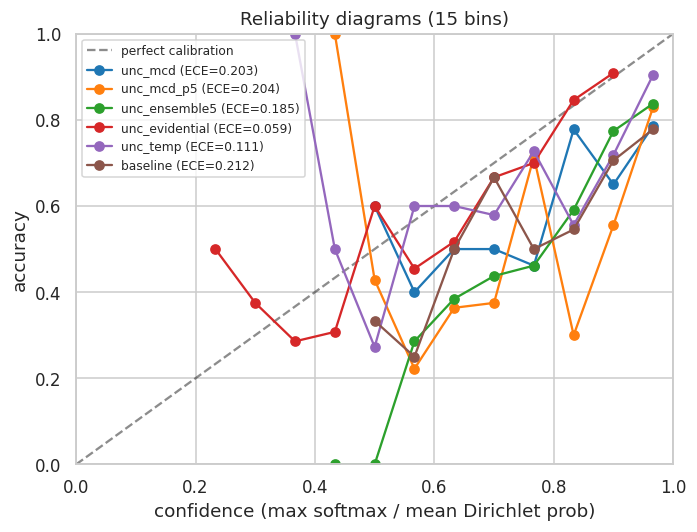

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.0))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect calibration")
palette = sns.color_palette("tab10", n_colors=len(eval_results))
for (name, er), colour in zip(eval_results.items(), palette):
    edges = np.asarray(er["ece"]["bin_edges"])
    centres = 0.5 * (edges[:-1] + edges[1:]) # plot at bin centre, not edge
    acc = np.asarray(er["ece"]["bin_acc"])
    count = np.asarray(er["ece"]["bin_count"])
    m = count > 0 # skip empty bins
    ax.plot(centres[m], acc[m], "o-", color=colour,
            label=f"{name} (ECE={er['ece']['ece']:.3f})")
ax.set_xlabel("confidence (max softmax / mean Dirichlet prob)")
ax.set_ylabel("accuracy"); ax.set_title("Reliability diagrams (15 bins)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(UNC_OUTPUT_DIR / "reliability_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()

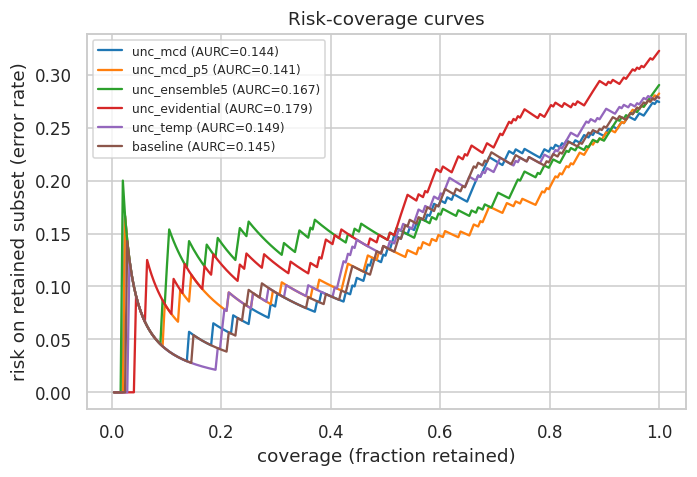

In [ ]:
# risk-coverage curves (lower is better)
# x = fraction kept (sorted by confidence), y = error rate on kept subset
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for (name, er), colour in zip(eval_results.items(), palette):
    ax.plot(er["sp"]["coverages"], er["sp"]["risks"], color=colour,
            label=f"{name} (AURC={er['sp']['aurc']:.3f})")
ax.set_xlabel("coverage (fraction retained)")
ax.set_ylabel("risk on retained subset (error rate)")
ax.set_title("Risk-coverage curves"); ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(UNC_OUTPUT_DIR / "risk_coverage_curves.png", dpi=150, bbox_inches="tight")
plt.show()

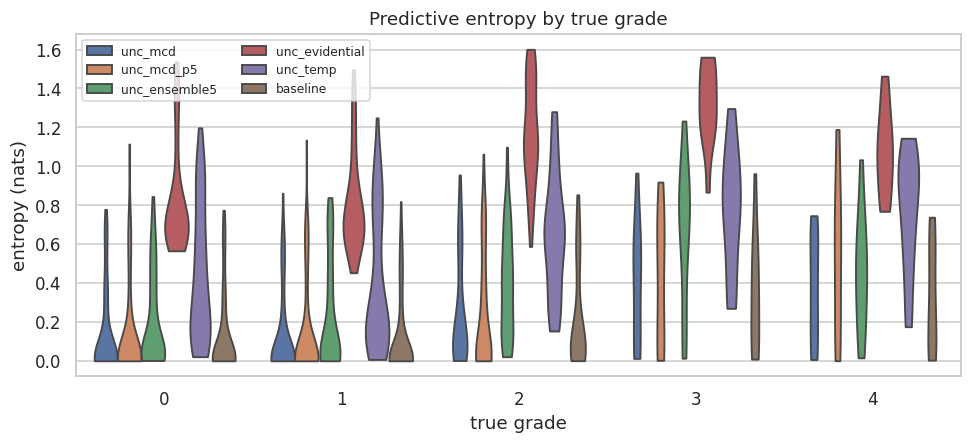

mean entropy per grade (rows: method, cols: grade)
grade               0      1      2      3      4
method                                           
baseline        0.125  0.119  0.224  0.340  0.329
unc_ensemble5   0.200  0.231  0.396  0.666  0.454
unc_evidential  0.825  0.809  1.178  1.319  1.077
unc_mcd         0.137  0.129  0.251  0.389  0.374
unc_mcd_p5      0.138  0.137  0.238  0.415  0.535
unc_temp        0.442  0.399  0.645  0.775  0.762


In [29]:
# entropy-by-grade violin
rows = [{"method": name, "grade": int(g), "entropy": float(h)}
        for name, out in method_outputs.items()
        for h, g in zip(out["entropy"], out["y_true"])]
ent_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.2))
# cut=0 so the violin doesn't extend past the observed range (clean edges)
sns.violinplot(data=ent_df, x="grade", y="entropy", hue="method",
               split=False, inner=None, ax=ax, cut=0)
ax.set_title("Predictive entropy by true grade")
ax.set_xlabel("true grade"); ax.set_ylabel("entropy (nats)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(UNC_OUTPUT_DIR / "entropy_by_grade_violin.png", dpi=150, bbox_inches="tight")
plt.show()

print("mean entropy per grade (rows: method, cols: grade)")
print(ent_df.groupby(["method", "grade"])["entropy"].mean().unstack().round(3))

In [31]:
# confusion matrix per method
short_names = [f"Grade {i}" for i in range(NUM_CLASSES)]
for name, out in method_outputs.items():
    if name == "baseline": continue
    cm = np.array(out["bundle"].confusion_matrix)
    fig = plot_confusion_matrix(cm, short_names, normalize=True,
                                save_path=UNC_OUTPUT_DIR / f"{name}_cm_test.png",
                                title=f"{name} - test confusion matrix")
    plt.close(fig)